## ROAD TRAFFIC ACCIDENT PREDICTION 


The main objective of this project is to develop a Machine Learning model that predicts the severity of road accidents based on driver, vehicle, road, weather, and accident-related factors. The model aims to classify accidents into Slight Injury, Serious Injury, or Fatal Injury, helping authorities improve road safety, emergency response, and traffic management through data-driven decision-making.

Import lib for this project 


In [86]:
import pandas as pd 
import numpy as numpy

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

In [88]:
import warnings

warnings.filterwarnings("ignore")

In [89]:
df = pd.read_csv("RTA Dataset.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (12316, 32)


,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [90]:
print("Shape of Dataset:", df.shape)
df.info()


Shape of Dataset: (12316, 32)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  R

In [91]:
print(df.columns.tolist())

['Time', 'Day_of_week', 'Age_band_of_driver', 'Sex_of_driver', 'Educational_level', 'Vehicle_driver_relation', 'Driving_experience', 'Type_of_vehicle', 'Owner_of_vehicle', 'Service_year_of_vehicle', 'Defect_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Number_of_vehicles_involved', 'Number_of_casualties', 'Vehicle_movement', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality', 'Pedestrian_movement', 'Cause_of_accident', 'Accident_severity']


In [92]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


In [93]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [94]:
print(df['Accident_severity'].value_counts())

Accident_severity
Slight Injury     10415
Serious Injury     1743
Fatal injury        158
Name: count, dtype: int64


plot Accident Severity 

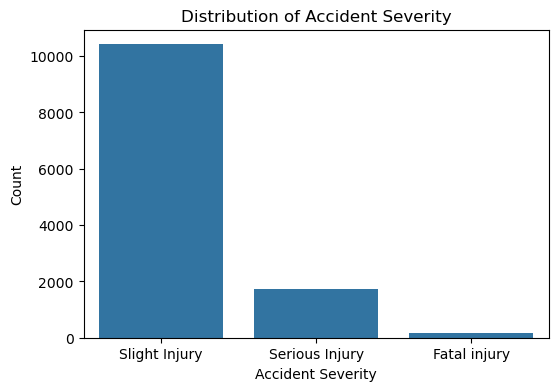

In [95]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Accident_severity',
    order=df['Accident_severity'].value_counts().index
)

plt.title("Distribution of Accident Severity")
plt.xlabel("Accident Severity")
plt.ylabel("Count")

plt.show()

In [96]:
# Check data types
print(df.dtypes)

Time                           object
Day_of_week                    object
Age_band_of_driver             object
Sex_of_driver                  object
Educational_level              object
Vehicle_driver_relation        object
Driving_experience             object
Type_of_vehicle                object
Owner_of_vehicle               object
Service_year_of_vehicle        object
Defect_of_vehicle              object
Area_accident_occured          object
Lanes_or_Medians               object
Road_allignment                object
Types_of_Junction              object
Road_surface_type              object
Road_surface_conditions        object
Light_conditions               object
Weather_conditions             object
Type_of_collision              object
Number_of_vehicles_involved     int64
Number_of_casualties            int64
Vehicle_movement               object
Casualty_class                 object
Sex_of_casualty                object
Age_band_of_casualty           object
Casualty_sev

In [97]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [98]:
# Check missing values
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 20057


In [99]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

In [100]:
number_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in number_columns:
    df[col] = df[col].fillna(df[col].median())

In [101]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 0


Feature Engineering

In [102]:

df['Hour'] = pd.to_datetime(df['Time']).dt.hour


df[['Time', 'Hour']].head()

,Time,Hour
0,17:02:00,17
1,17:02:00,17
2,17:02:00,17
3,1:06:00,1
4,1:06:00,1


Why do we create the Hour column?

Machine learning models cannot easily learn from a full time value like 17:32:45. What matters more is which hour of the day the accident happened.


In simple explain 

We convert the Time column into an Hour column because the hour of the accident is more useful for finding patterns. Machine learning models can better understand whether an accident happened in the morning, afternoon, evening, or night than the exact time with minutes and seconds

then remove time column 

In [103]:
# Remove Time column
df.drop('Time', axis=1, inplace=True)

In [104]:
# Remove data leakage columns
df.drop([
    'Casualty_class',
    'Sex_of_casualty',
    'Age_band_of_casualty',
    'Fitness_of_casuality'
], axis=1, inplace=True)

In [105]:
print(df.shape)
df.head()

(12316, 28)


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Work_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,No defect,...,Collision with roadside-parked vehicles,2,2,Going straight,na,Unknown,Not a Pedestrian,Moving Backward,Slight Injury,17
1,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,No defect,...,Vehicle with vehicle collision,2,2,Going straight,na,Unknown,Not a Pedestrian,Overtaking,Slight Injury,17
2,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,Unknown,No defect,...,Collision with roadside objects,2,2,Going straight,3,Driver,Not a Pedestrian,Changing lane to the left,Serious Injury,17
3,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,Unknown,No defect,...,Vehicle with vehicle collision,2,2,Going straight,3,Driver,Not a Pedestrian,Changing lane to the right,Slight Injury,1
4,Sunday,18-30,Male,Junior high school,Employee,2-5yr,Unknown,Owner,5-10yrs,No defect,...,Vehicle with vehicle collision,2,2,Going straight,na,Unknown,Not a Pedestrian,Overtaking,Slight Injury,1


Import LabelEncoder

In [106]:
from sklearn.preprocessing import LabelEncoder

In [107]:
le = LabelEncoder()

In [108]:
# Find all text columns
text_columns = df.select_dtypes(include='object').columns

# Convert text to numbers
for col in text_columns:
    df[col] = le.fit_transform(df[col])

In [109]:
df.head()


,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,Defect_of_vehicle,...,Type_of_collision,Number_of_vehicles_involved,Number_of_casualties,Vehicle_movement,Casualty_severity,Work_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity,Hour
0,1,0,1,0,0,0,0,3,3,2,...,3,2,2,2,3,6,5,9,2,17
1,1,1,1,4,0,3,11,3,2,2,...,8,2,2,2,3,6,5,16,2,17
2,1,0,1,4,0,0,5,3,5,2,...,2,2,2,2,2,0,5,0,1,17
3,3,0,1,4,0,2,11,0,5,2,...,8,2,2,2,2,0,5,1,2,1
4,3,0,1,4,0,1,17,3,2,2,...,8,2,2,2,3,6,5,16,2,1


Why do we use Label Encoding?

Machine learning algorithms work with numbers, not text. Label Encoding converts each unique text category into a unique number so the model can process the data.

In [110]:
# Features (Input)
X = df.drop('Accident_severity', axis=1)

# Target (Output)
y = df['Accident_severity']

In [111]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (12316, 27)
Target Shape: (12316,)


In [112]:
from sklearn.model_selection import train_test_split

In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [114]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (9237, 27)
Testing Data: (3079, 27)


Import Multiple Models

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

Train Logistic Regression 

In [116]:
# Logistic Regression
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

lr.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

Train Decision Tree

In [117]:
# Decision Tree
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

Train Random Forest

In [118]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Check Training Model Completed

In [119]:
print(" Logistic Regression Trained")
print(" Decision Tree Trained")
print(" Random Forest Trained")

 Logistic Regression Trained
 Decision Tree Trained
 Random Forest Trained


Why do we train three models?

We train multiple models to compare their performance and choose the one that predicts accident severity most accurately.

In [120]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [121]:
# Predictions
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [122]:
# Accuracy of each model
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.4930172133809678
Decision Tree Accuracy: 0.7755764858720364
Random Forest Accuracy: 0.8470282559272491


In [123]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.02      0.36      0.04        39
           1       0.17      0.33      0.22       436
           2       0.87      0.52      0.65      2604

    accuracy                           0.49      3079
   macro avg       0.35      0.40      0.30      3079
weighted avg       0.76      0.49      0.58      3079



In [124]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.02      0.36      0.04        39
           1       0.17      0.33      0.22       436
           2       0.87      0.52      0.65      2604

    accuracy                           0.49      3079
   macro avg       0.35      0.40      0.30      3079
weighted avg       0.76      0.49      0.58      3079



In [125]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Random Forest Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       1.00      0.01      0.02       436
           2       0.85      1.00      0.92      2604

    accuracy                           0.85      3079
   macro avg       0.62      0.34      0.31      3079
weighted avg       0.86      0.85      0.78      3079



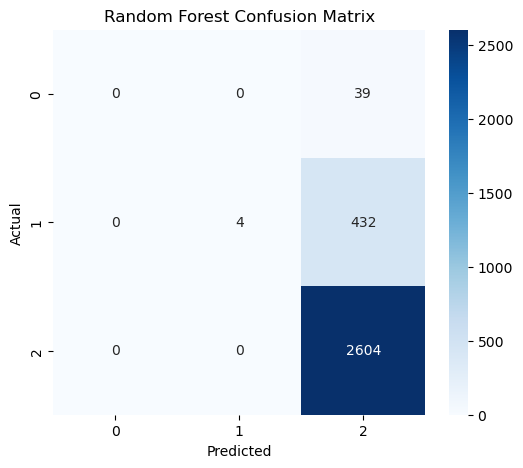

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

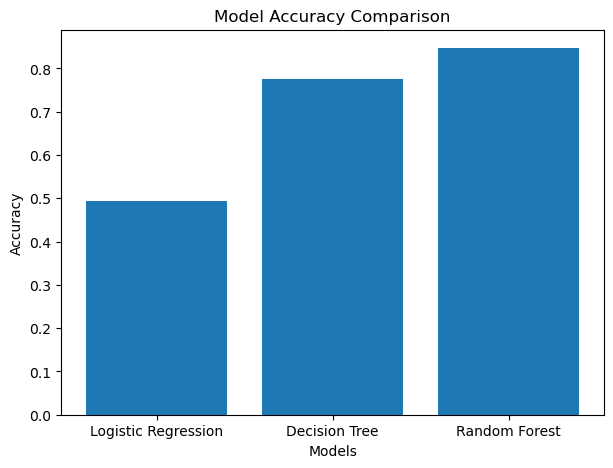

In [127]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

Why do we use Accuracy?

Accuracy tells us the percentage of correct predictions made by the model.

Why do we use a Confusion Matrix?

It shows how many predictions were correct and where the model made mistakes for each class.

Why do we compare three models?

To find which model performs best for predicting accident severity.

In [128]:
# Feature Importance
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
26,Hour,0.095568
20,Number_of_casualties,0.090992
25,Cause_of_accident,0.064438
0,Day_of_week,0.062054
6,Type_of_vehicle,0.058722
1,Age_band_of_driver,0.048753
19,Number_of_vehicles_involved,0.048248
10,Area_accident_occured,0.047414
5,Driving_experience,0.047363
13,Types_of_Junction,0.043331


Feature Importance is used to identify which input features have the greatest impact on the Random Forest model’s predictions. It helps us understand how the model makes decisions and which factors are most influential in predicting accident severity.

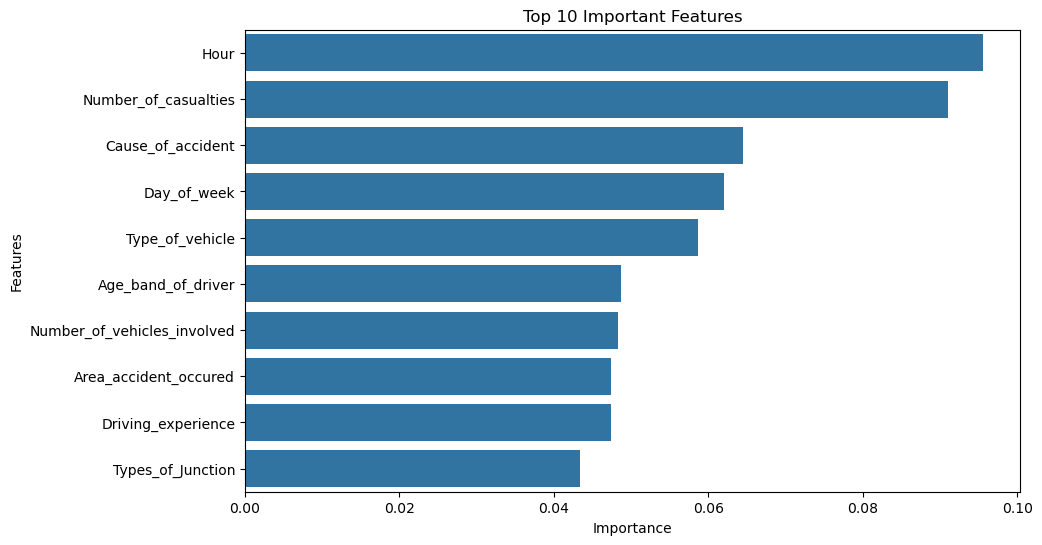

In [129]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.show()

In [130]:
# Select one sample from the test data
sample = X_test.iloc[[0]]

# Predict accident severity
prediction = rf.predict(sample)

print("Predicted Severity:", prediction[0])

Predicted Severity: 2


In [131]:
print("Actual Severity:", y_test.iloc[0])

Actual Severity: 2


In [133]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df['Accident_severity'] = target_encoder.fit_transform(df['Accident_severity'])

In [134]:
print("Predicted:", target_encoder.inverse_transform(prediction)[0])
print("Actual:", target_encoder.inverse_transform([y_test.iloc[0]])[0])

Predicted: 2
Actual: 2


In [135]:
print(le.classes_)

['Fatal injury' 'Serious Injury' 'Slight Injury']


Project Explanation

In this project, I developed a machine learning model to predict the severity of road accidents. The main goal was to identify whether an accident would result in Slight Injury, Serious Injury, or Fatal Injury based on different factors such as weather conditions, road conditions, driver details, vehicle information, and accident details.

First, I imported the required Python libraries and loaded the dataset. Then, I explored the dataset by checking the number of rows and columns, data types, missing values, and the distribution of the target variable. After understanding the data, I cleaned the dataset by handling all missing values. I filled missing values in categorical columns with “Unknown” and numerical columns with their median values.

Next, I performed feature engineering by extracting the Hour from the Time column because the hour is more useful for finding accident patterns than the exact time. I also removed some casualty-related columns because they contain information that would only be available after an accident, which could affect the model’s fairness.

After preprocessing, I converted all categorical data into numerical values using Label Encoding. Then, I separated the input features and the target variable and split the dataset into training and testing data. I trained three machine learning models: Logistic Regression, Decision Tree, and Random Forest.

Finally, I evaluated all three models using Accuracy, Classification Report, and Confusion Matrix. Among them, the Random Forest model performed the best with an accuracy of 84.70%, while the Decision Tree achieved 77.56% and Logistic Regression achieved 49.30%. I also checked the feature importance to understand which factors had the greatest influence on accident severity and tested the model on a sample accident record.

Overall, this project helped me understand the complete machine learning process, including data preprocessing, feature engineering, model training, evaluation, and prediction. It also showed how machine learning can be used to support road safety and improve emergency response by predicting accident severity.